<a href="https://colab.research.google.com/github/Colosolizer/carisurg-portfolio/blob/setup-folders/Week_5_Assignment_SekouRuddock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 5 Carisurg Interim Assignment

# PANDAS SETUP AND DATA IMPORT

In [9]:
#Import Pandas and Numpy to handle data and numbers
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

#Import Dataset from google drive
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/ColabNotebooks/Carisurg_2026/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Unable to find {DATA_PATH}.")

Environment ready · pandas 2.2.2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Read Dataset from file
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

Loaded 55,121 ED encounters  x  225 columns


# IDENTIFYING STRUCTURED COLUMNS

In [11]:
#Print Identified Columns
print("Total columns:", df.shape[1], "\n")

structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

print(f"Structured columns ({len(structured)}):")
for c in structured:
    print("   ", c)
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}  ->  grouped by body system in section 5")

Total columns: 225 

Structured columns (25):
    dep_name
    esi
    age
    gender
    ethnicity
    race
    lang
    religion
    maritalstatus
    employstatus
    insurance_status
    disposition
    arrivalmode
    arrivalmonth
    arrivalday
    arrivalhour_bin
    previousdispo
    triage_vital_hr
    triage_vital_sbp
    triage_vital_dbp
    triage_vital_rr
    triage_vital_o2
    triage_vital_o2_device
    triage_vital_temp
    triage_glucose

Chief-complaint flags (cc_*): 200  ->  grouped by body system in section 5


# IDENTIFYING COLUMN DATA TYPES

In [12]:
#Printing datatypes for each column
print("Column types :")
print(df.dtypes.value_counts(), "\n")

# Strutural Column Summary and the first three columns
df[structured].info()
df[["esi", "age", "gender", "race", "triage_vital_hr", "triage_vital_sbp", "disposition"]].head(3)

Column types :
float64    210
object      15
Name: count, dtype: int64 

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object 
 13  arrivalmonth          

,esi,age,gender,race,triage_vital_hr,triage_vital_sbp,disposition
7,4.0,87.0,Female,Other,88.0,155.0,Discharge
17,2.0,53.0,Male,Other,118.0,105.0,Admit
40,2.0,49.0,Female,White or Caucasian,76.0,116.0,Discharge


# PATIENT AGE AND VITAL SIGNS

In [13]:
# Summarizes and Prints patient age
print("AGE (years):")
print(df["age"].describe().round(1), "\n")

for col in ["gender", "race", "ethnicity", "disposition"]:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False), "\n")



# Clinical reference ranges (general adult triage) in FAHRENHEIT
NORMAL_RANGES = {
    "triage_vital_hr":   (60, 100, "bpm"),
    "triage_vital_sbp":  (90, 140, "mmHg"),
    "triage_vital_dbp":  (60,  90, "mmHg"),
    "triage_vital_rr":   (12,  20, "/min"),
    "triage_vital_o2":   (95, 100, "%"),
    "triage_vital_temp": (97.0, 99.5, "F"),   # NOT Celsius
    "triage_glucose":    (70, 140, "mg/dL"),
}
VITALS = list(NORMAL_RANGES)

#Vitals Summary
print(df[VITALS].describe().round(1))

print("\nOn a supplemental-O2 device?  (0 = room air, 1 = device)")
print(df["triage_vital_o2_device"].value_counts(dropna=False))

AGE (years):
count    55121.0
mean        55.3
std         19.5
min         18.0
25%         40.0
50%         55.0
75%         70.0
max        107.0
Name: age, dtype: float64 

gender:
gender
Female    31744
Male      23377
Name: count, dtype: int64 

race:
race
White or Caucasian                           29435
Black or African American                    15963
Other                                         9016
Patient Refused                                370
Asian                                          175
Unknown                                         76
American Indian or Alaska Native                66
Native Hawaiian or Other Pacific Islander       20
Name: count, dtype: int64 

ethnicity:
ethnicity
Non-Hispanic          45142
Hispanic or Latino     9888
Patient Refused          56
Unknown                  35
Name: count, dtype: int64 

disposition:
disposition
Discharge    34565
Admit        20556
Name: count, dtype: int64 

       triage_vital_hr  triage_vital_sbp  triage_

# Cheif Complaints by Body System

In [14]:
cc_flags = [c for c in df.columns if c.startswith("cc_")]

#Sorting all 200 flags into ~12 clinical categories.
CC_CATEGORIES = [
    ("Cardiovascular",             ["chestpain","chesttightness","palpitation","irregularheart","rapidheart","tachycard","hypertens","hypotens","cardiacarrest"]),
    ("Genitourinary/Renal",        ["dysuria","hematuria","urinary","flank","testicle","maleguproblem","femaleguproblem","groin","pelvic","vaginal","breastpain","std"]),
    ("Respiratory",                ["breathing","shortnessofbreath","dyspnea","cough","wheez","respiratory","asthma","hemoptysis","coldlike","nasalcongest","influenza","sinus","sorethroat","uri"]),
    ("Neurological",               ["headache","migraine","dizz","syncope","seizure","stroke","alteredmental","confusion","numbness","lossofconsciousness","unresponsive","lethargy","neurologic","hallucinat","extremityweakness"]),
    ("Gastrointestinal",           ["abdominal","epigastric","nausea","emesis","vomit","diarrhea","constipation","gibleeding","giproblem","rectal","swallowedforeign","ingestion","dehydration"]),
    ("Psych/Behavioral/Substance", ["anxiety","depress","agitation","suicid","homicid","psychot","psychiatric","panic","alcohol","drugproblem","drug/alcohol","addiction","detox","overdose","withdrawal","poison"]),
    ("ENT/Eye/Dental",             ["earpain","earproblem","otalgia","eye","conjunctiv","foreignbodyineye","blurredvision","dental","jaw","epistaxis","facial","oralswelling"]),
    ("Skin/Soft-tissue",           ["rash","cellulitis","abscess","cyst","skin","wound","mass","allergicreaction","edema","bruising"]),
    ("Endocrine/Metabolic/Heme",   ["bloodsugar","glycem","glucose","sicklecell"]),
    ("Constitutional/General",     ["fever","chills","fatigue","bodyache","generalizedbody","weakness"]),
    ("Trauma/Injury/MSK",          ["injury","fall","trauma","laceration","fracture","back","neck","joint","rib","assault","burn","animalbite","insectbite","pain","swelling"]),
]

def categorize(flag):
    stem = flag[3:]
    if "crash" in stem:
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

# Confirming all flags were placed  in a category
from collections import defaultdict
groups = defaultdict(list)
for flag in cc_flags:
    groups[categorize(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")
print("-" * 40)
print(f"{'TOTAL placed':28s} {sum(len(v) for v in groups.values()):3d} of {len(cc_flags)}")

Cardiovascular                 9 flags
Genitourinary/Renal           17 flags
Respiratory                   15 flags
Neurological                  21 flags
Gastrointestinal              16 flags
Psych/Behavioral/Substance    18 flags
ENT/Eye/Dental                18 flags
Skin/Soft-tissue              14 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         8 flags
Trauma/Injury/MSK             49 flags
Other/Procedural/Admin        10 flags
----------------------------------------
TOTAL placed                 200 of 200


# How many patients had a specific complaint and the most common complaints

In [15]:
# (1) Totals per body system: sum every flag in the category, across all patients.
print("Complaint volume by body system (flag-hits across all encounters):")
system_totals = {name: int(df[flags].sum().sum()) for name, flags in groups.items()}
for name in sorted(system_totals, key=system_totals.get, reverse=True):
    print(f"   {name:28s} {system_totals[name]:>7,}")

# (2) The most common individual complaints overall.
per_flag = df[cc_flags].sum().sort_values(ascending=False)
print("\nTop 5 individual complaints:")
print(per_flag.head(5))
print("\nComplaint flags that never fire in this sample:", int((per_flag == 0).sum()))

Complaint volume by body system (flag-hits across all encounters):
   Trauma/Injury/MSK             13,094
   Gastrointestinal              10,542
   Respiratory                    6,693
   Other/Procedural/Admin         6,551
   Neurological                   5,957
   Cardiovascular                 4,912
   Psych/Behavioral/Substance     4,189
   Genitourinary/Renal            3,418
   Constitutional/General         3,032
   Skin/Soft-tissue               2,464
   ENT/Eye/Dental                 1,571
   Endocrine/Metabolic/Heme         875

Top 5 individual complaints:
cc_abdominalpain        6717.0
cc_other                4491.0
cc_chestpain            3712.0
cc_shortnessofbreath    3098.0
cc_backpain             1997.0
dtype: float64

Complaint flags that never fire in this sample: 1


# ESI Database Check and Leakage Check

In [16]:
#CHECKS ESI LEVEL DISTRIBUTION IN THE DATASET
counts = df["esi"].value_counts(dropna=False).sort_index()
pct    = (counts / len(df) * 100).round(1)
print("ESI (Triage_Level) distribution:")
for level in counts.index:
    print(f"   ESI {level:>3}   {counts[level]:>7,}   ({pct[level]:>4}%)")
print("\nMissing labels:", int(df["esi"].isna().sum()))

#PRINTS ESI LABELS AND THE NUMBER OF CASES FOUND AT THAT LEVEL
labels = {1: "Resuscitation", 2: "Emergent", 3: "Urgent", 4: "Less urgent", 5: "Non-urgent"}
counts = df["esi"].value_counts().sort_index()
print("ESI  ·  name           ·  encounters")
for level, n in counts.items():
    print(f"   {int(level)}  ·  {labels[int(level)]:<13}  ·  {n:>7,}")

ESI (Triage_Level) distribution:
   ESI 1.0        77   ( 0.1%)
   ESI 2.0    17,924   (32.5%)
   ESI 3.0    27,010   (49.0%)
   ESI 4.0     8,896   (16.1%)
   ESI 5.0     1,214   ( 2.2%)

Missing labels: 0
ESI  ·  name           ·  encounters
   1  ·  Resuscitation  ·       77
   2  ·  Emergent       ·   17,924
   3  ·  Urgent         ·   27,010
   4  ·  Less urgent    ·    8,896
   5  ·  Non-urgent     ·    1,214


SCHEMA MAP TO SORT INTO FAMILIES

In [17]:
#Import matlib for plotting
import matplotlib.pyplot as plt    # plotting


In [18]:

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit —
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.

    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # Cheif Complaints List
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [19]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}


PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [20]:
#PLACING ALL STRUCTURED COLUMNS TOGETHER
fam = classify_columns(df)
# "structured" = the non-chief-complaint columns (everything not starting with "cc_").
structured = [col for col in df.columns if not col.startswith("cc_")]

# ANALYZING MISSINGNESS

In [21]:
# FRACTION MISSING PER COLUMN
missing_fraction = df[structured].isna().mean()

# TURN INTO A PERCENTAGE
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# COLUMNS WITH GAPS
missing_percent[missing_percent > 0]

,0


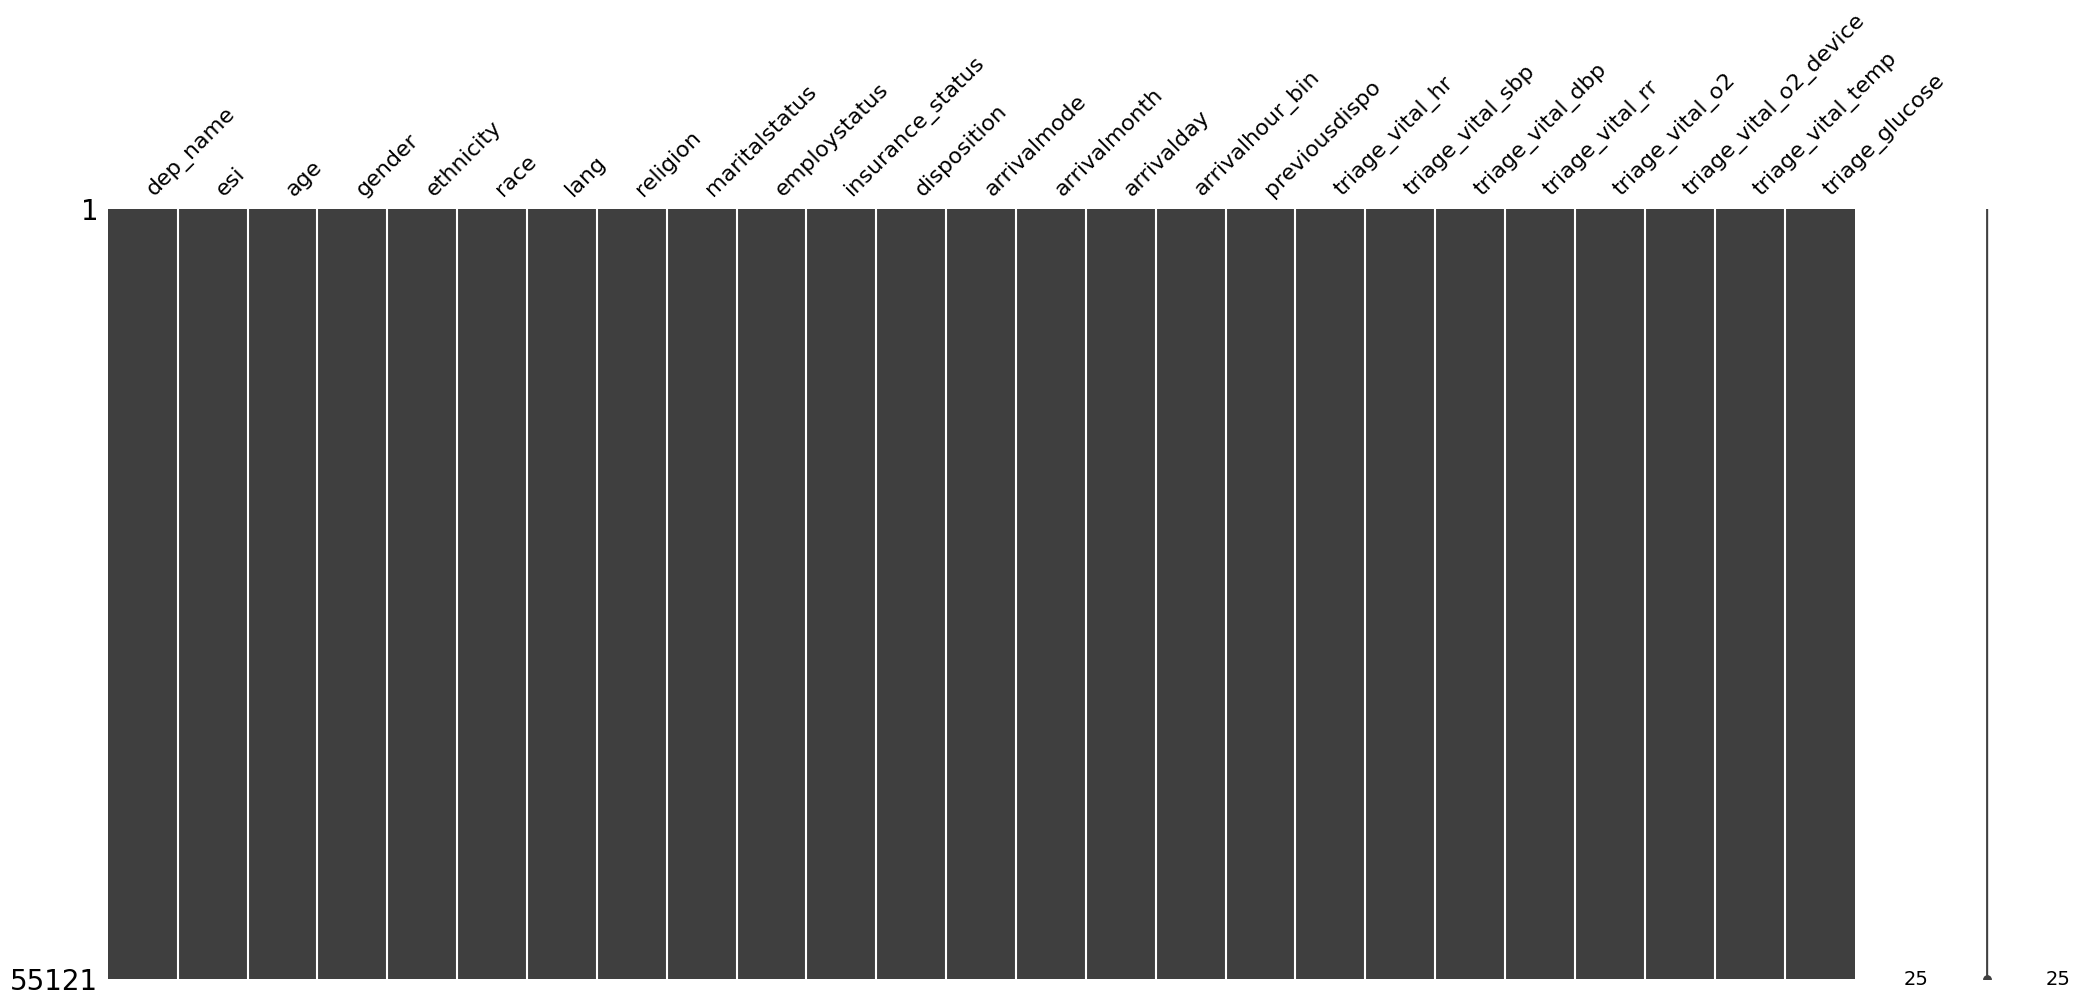

In [22]:
# Missingness map of the structured block
try:
    import missingno as msno
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

In [23]:
#Dtype audit + target sanity
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


# HISTOGRAM FOR VITALS

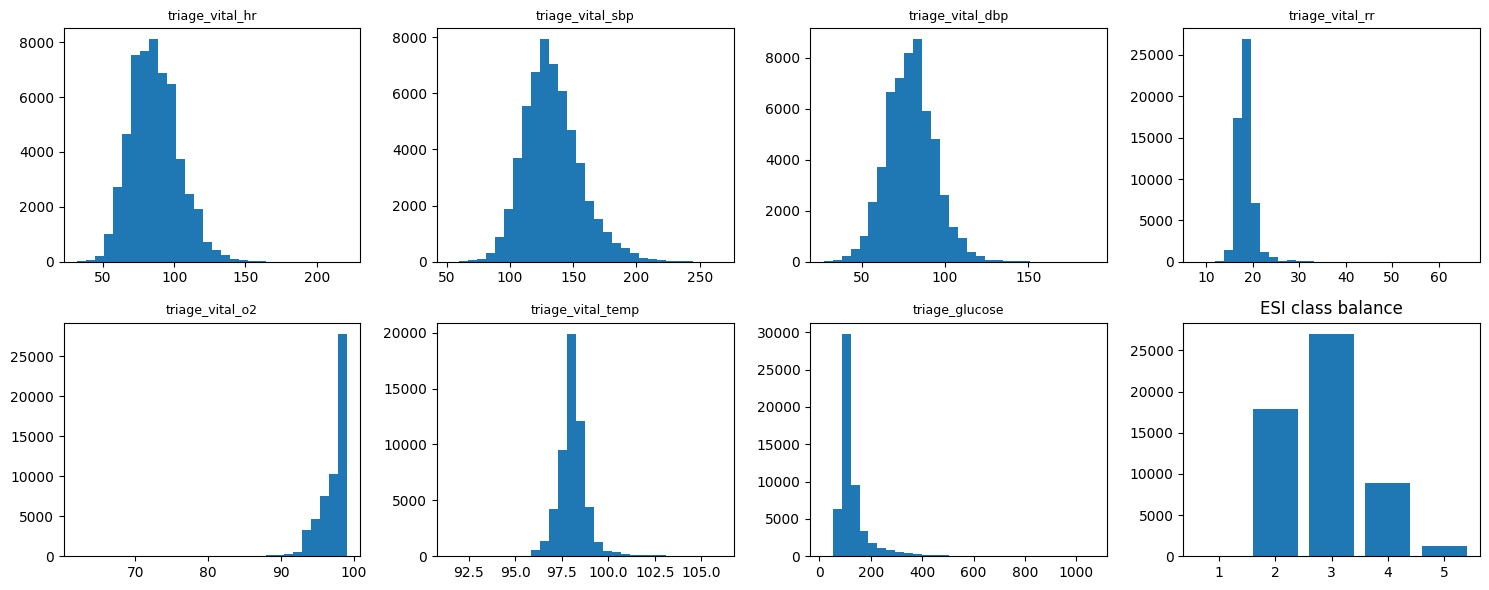

In [24]:
#HISTOGRAM DISTRIBUTION FOR EACH VITAL
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()

In [25]:
# Demographics — the fairness-sensitive view
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


# FINDING OUTLIERS

In [26]:
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()


    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2366,4
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5673,25


# Measure how each vital and each chief complaint correlates with ESI

In [27]:
# Make a numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")


vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))


cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\n Chief Complaints vs ESI:")
print(cc_corr.head(8).round(3))


Vital vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64

 Chief Complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [28]:
#CREATES A TABLE SHOWCASING DATA QUALITY ISSUES
issues = [
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"},
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"},
    {"issue": "Missing ESI label", "columns": "esi", "action": "drop rows w/o target"}

]
pd.DataFrame(issues)

,issue,columns,action
0,Missing ESI label,esi,drop rows w/o target
1,Missing ESI label,esi,drop rows w/o target
2,Missing ESI label,esi,drop rows w/o target


# OUTLIER REPORT AND ISSUES TABLE

In [29]:
print("\n--- Triage_vital_o2 Missingness vs. ESI Acuity ---")
missing_o2 = df['triage_vital_o2'].isna()

if missing_o2.any():
    print("ESI distribution for rows with missing triage_vital_o2:")
    print(df.loc[missing_o2, TARGET].value_counts(normalize=True).sort_index().round(3))
else:
    print("No missing values in triage_vital_o2.")

print("\nESI distribution for rows with present triage_vital_o2:")
print(df.loc[~missing_o2, TARGET].value_counts(normalize=True).sort_index().round(3))


print("\n--- Chief Complaint Column Prevalence Analysis ---")
# Calculate prevalence for each chief complaint column
cc_prevalence = df[fam["chief_complaints"]].mean()

# Identify columns with prevalence < 0.5% (0.005)
low_prevalence_cc = cc_prevalence[cc_prevalence < 0.005]

print(f"Number of chief complaint columns with <0.5% prevalence: {len(low_prevalence_cc)}")
print("Examples of low prevalence cc_ columns:")
print(low_prevalence_cc.sort_values().head())

print("\nImplications for modeling: Columns with very low prevalence might be nearly constant and provide little predictive power. They could be considered for removal or special handling (e.g., grouping rare categories) to avoid issues like sparse features or overfitting.")


print("\n--- Data Quality Issues Table ---")
# Recreate the issues list and add new findings
issues = [
    {"issue": "Target column 'esi' has no missing labels", "columns": "esi", "action": "No action needed"},
]

# Add issues from impossible outliers
for col in fam["vitals"]:
    report = outlier_report(df, col)
    if report["impossible"] > 0:
        issues.append({"issue": f"Impossible values in {col}", "columns": col, "action": "Investigate data entry error, clip, or impute"})
    if report["iqr_outliers"] > 0:
        # Not adding all IQR outliers as an explicit 'issue' unless it's very severe
        # as IQR outliers are common and not always data quality problems.
        pass

# Add issues from low prevalence chief complaints
if not low_prevalence_cc.empty:
    issues.append({"issue": f"Low prevalence ( < 0.5%) in {len(low_prevalence_cc)} chief complaint columns", "columns": ', '.join(low_prevalence_cc.index.tolist()[:3]) + '...', "action": "Consider removing or grouping these columns, or using models robust to sparse features."})

pd.DataFrame(issues)


--- Triage_vital_o2 Missingness vs. ESI Acuity ---
No missing values in triage_vital_o2.

ESI distribution for rows with present triage_vital_o2:
esi
1.0    0.001
2.0    0.325
3.0    0.490
4.0    0.161
5.0    0.022
Name: proportion, dtype: float64

--- Chief Complaint Column Prevalence Analysis ---
Number of chief complaint columns with <0.5% prevalence: 149
Examples of low prevalence cc_ columns:
cc_cardiacarrest        0.000000
cc_fulltrauma           0.000073
cc_ingestion            0.000181
cc_bodyfluidexposure    0.000181
cc_exposuretostd        0.000236
dtype: float64

Implications for modeling: Columns with very low prevalence might be nearly constant and provide little predictive power. They could be considered for removal or special handling (e.g., grouping rare categories) to avoid issues like sparse features or overfitting.

--- Data Quality Issues Table ---


,issue,columns,action
0,Target column 'esi' has no missing labels,esi,No action needed
1,Impossible values in triage_vital_rr,triage_vital_rr,"Investigate data entry error, clip, or impute"
2,Impossible values in triage_glucose,triage_glucose,"Investigate data entry error, clip, or impute"
3,Low prevalence ( < 0.5%) in 149 chief complain...,"cc_abdominalcramping, cc_abdominaldistention, ...","Consider removing or grouping these columns, o..."


# SIX PLOT DASHBOARD FOR MEMO

In [30]:
#CLEANING UP EVERYTHING, MAKING A CLEANED COPY
import os
def clean_triage(raw):
    d = raw.copy()
    fam = classify_columns(d)

    # Drop rows with no triage label
    d = d[d[TARGET].notna()].copy()

    #  Make the vital-sign columns (and age) numeric.
    numeric_cols = list(fam["vitals"])
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Flag physiologically impossible values
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # Fill the gaps. Vitals -> median
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # Target should be a whole number 1-5
    d[TARGET] = d[TARGET].round().astype(int)
    return d

IMPORT CLEANED DATASET

In [31]:
from pathlib import Path
CLEAN_PATH, RAW_PATH = Path("triage_cleaned_v1.csv"), Path("/content/drive/MyDrive/ColabNotebooks/Carisurg_2026/yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Rebuilt from raw via clean_triage()
(55121, 225)


# MISSING CELL GRID PLOT

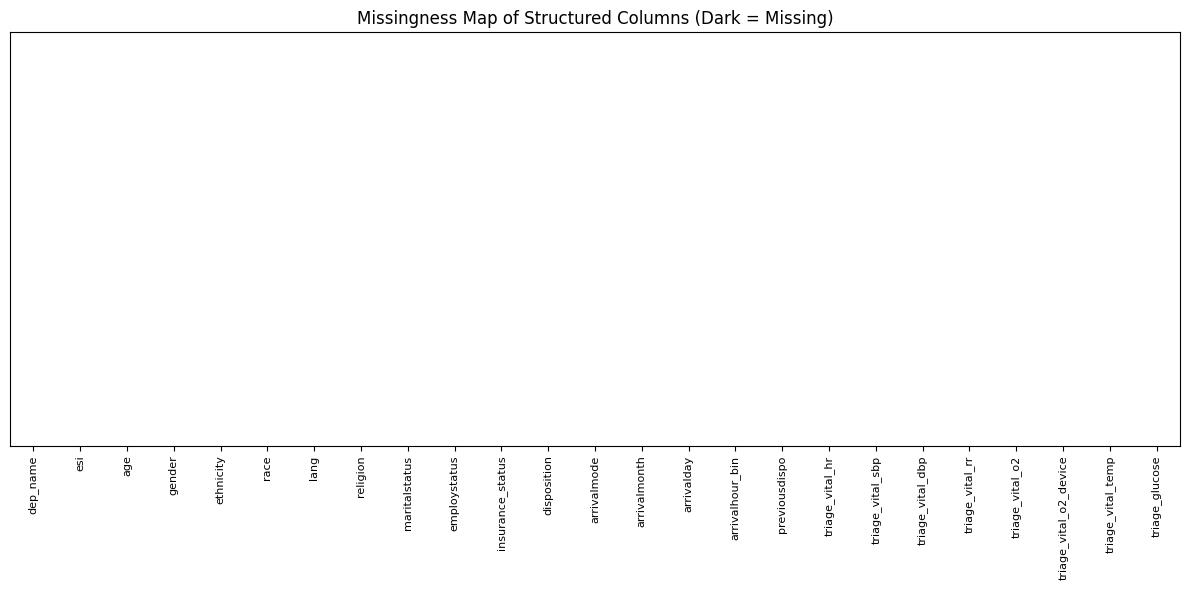

In [32]:
import matplotlib.pyplot as plt

src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

# draw a missingness map of src[structured] and save it.
# the missing-cell grid is src[structured].isna().values   (True where missing)
# make a figure + axes with plt.subplots(...)
# paint the grid with ax.imshow(...); look up the aspect= and cmap= args so missing reads as dark
# label the columns with ax.set_xticks(...) and ax.set_xticklabels(...) (rotate them so they fit)
# finish: plt.tight_layout(), then plt.savefig("figs/01_missingness.png", dpi=110), then plt.show()

missing_grid = src[structured].isna().values

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(missing_grid, aspect="auto", cmap="gray_r") # 'gray_r' makes missing (True) dark

ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=8)
ax.set_yticks([]) # No y-ticks needed for this plot
ax.set_title("Missingness Map of Structured Columns (Dark = Missing)")

plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()